# 블로그 핵심어 추출 결과 분석
- 데이터: `data/processed/blog_with_keywords.csv`

**처리 순서**
1. 공백 / 빈 값 제거
2. 가짜 키워드 필터링
3. 키워드 개수 파악 및 재추출
4. 본격 키워드 분석


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
CSV_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'blog_with_keywords.csv')

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
df['본문내용']        = df['본문내용'].fillna('')
df['review_keywords'] = df['review_keywords'].fillna('')
df['hin_keywords']    = df['hin_keywords'].fillna('')
df['본문길이'] = df['본문내용'].str.len()

print(f'원본 전체: {len(df):,}건')

원본 전체: 8,120건


## Step 1. 공백 / 빈 값 제거
- `review_keywords`가 비어있거나 공백만 있는 행 제거 (LLM skip 또는 추출 실패)


In [17]:
def is_blank(s):
    return not s or not s.strip()

review_blank = df['review_keywords'].apply(is_blank)
hin_blank    = df['hin_keywords'].apply(is_blank)

print('=== 공백/빈 값 현황 ===')
print(f'review_keywords 빈 행: {review_blank.sum():,}건 ({review_blank.sum()/len(df)*100:.1f}%)')
print(f'hin_keywords    빈 행: {hin_blank.sum():,}건 ({hin_blank.sum()/len(df)*100:.1f}%)')
print()

review_blank_body = df[review_blank & (df['본문길이'] >= 100)]
print(f'본문 >=100자인데 review 빈 행 (추출 실패 의심): {len(review_blank_body)}건')
if len(review_blank_body) > 0:
    print(review_blank_body[['검색어', '본문길이']].head(10).to_string(index=False))
print()

df_s1 = df[~review_blank].copy()
print(f'Step 1 후 남은 행: {len(df_s1):,}건  (제거: {len(df)-len(df_s1):,}건)')


=== 공백/빈 값 현황 ===
review_keywords 빈 행: 391건 (4.8%)
hin_keywords    빈 행: 397건 (4.9%)

본문 >=100자인데 review 빈 행 (추출 실패 의심): 3건
                    검색어   본문길이
    세븐일레븐 아이)뽀로로피리캔디17g  53633
       세븐일레븐 시원)다이노월드8g 205227
세븐일레븐 인스터)모짜르트하우스화이트187 223229

Step 1 후 남은 행: 7,729건  (제거: 391건)


## Step 2. 가짜 키워드 필터링
- LLM이 키워드를 못 찾을 때 반환하는 의미 없는 토큰 포함 행 제거
- 탐지 방식: 각 토큰을 정규화(소문자+공백제거) 후 FAKE_SUBSTRINGS 포함 여부 체크 (substring matching)
- `맛없음`, `부담없음` 등은 FAKE_SUBSTRINGS에 해당 없으므로 오탐 없음
- 실제 발견된 fake 패턴: `해당 없음`, `정보 없음`, `후기본문추출실패`, `없음`(단독)

In [ ]:
# 정규화 후 substring 포함 여부로 fake 탐지
# '없음' 단독 토큰은 exact match, 나머지는 substring match
FAKE_SUBSTRINGS = {'해당없음', '해당사항없음', '관련없음', '정보없음', '후기본문추출실패', 'n/a'}
FAKE_EXACT      = {'없음'}

def has_fake(s):
    if not s: return False
    for k in s.split(','):
        norm = k.strip().lower().replace(' ', '')
        if not norm:
            continue
        if norm in FAKE_EXACT:
            return True
        if any(sub in norm for sub in FAKE_SUBSTRINGS):
            return True
    return False

def get_fake_tokens(s):
    result = []
    if not s: return result
    for k in s.split(','):
        norm = k.strip().lower().replace(' ', '')
        if not norm: continue
        if norm in FAKE_EXACT or any(sub in norm for sub in FAKE_SUBSTRINGS):
            result.append(k.strip())
    return result

review_fake = df_s1['review_keywords'].apply(has_fake)
hin_fake    = df_s1['hin_keywords'].apply(has_fake)
either_fake = review_fake | hin_fake

print('=== 가짜 키워드 현황 (Step 1 통과 행 기준) ===')
print(f'review_keywords fake 포함: {review_fake.sum()}건')
print(f'hin_keywords    fake 포함: {hin_fake.sum()}건')
print(f'fake 포함 행 합계:         {either_fake.sum()}건')
print()

fake_counter = Counter()
for s in df_s1['review_keywords'].tolist() + df_s1['hin_keywords'].tolist():
    fake_counter.update(get_fake_tokens(s))
if fake_counter:
    print('=== fake 토큰 등장 횟수 ===')
    for kw, cnt in fake_counter.most_common():
        print(f'  {repr(kw)}: {cnt}건')
    print()
    print('=== fake 포함 행 전체 ===')
    print(df_s1[either_fake][['검색어', '본문길이', 'review_keywords', 'hin_keywords']].to_string(index=False))
    print()

df_s2 = df_s1[~either_fake].copy()
print(f'Step 2 후 남은 행: {len(df_s2):,}건  (제거: {either_fake.sum()}건)')

## Step 3. 키워드 개수 파악 및 재추출
- 정제된 `df_s2` 기준 키워드 개수 분포 확인
- 이상치(review ≤3 또는 hin ≤3) 목록 확인
- 재추출 결과 비교 (`batch_blog_reextract.py` 실행 후)


=== review_keywords 개수 통계 ===
count    7722.00
mean        5.72
std         0.86
min         1.00
25%         5.00
50%         6.00
75%         6.00
max         8.00
Name: review_n, dtype: float64

=== hin_keywords 개수 통계 ===
count    7722.00
mean        4.97
std         0.61
min         0.00
25%         5.00
50%         5.00
75%         5.00
max         8.00
Name: hin_n, dtype: float64



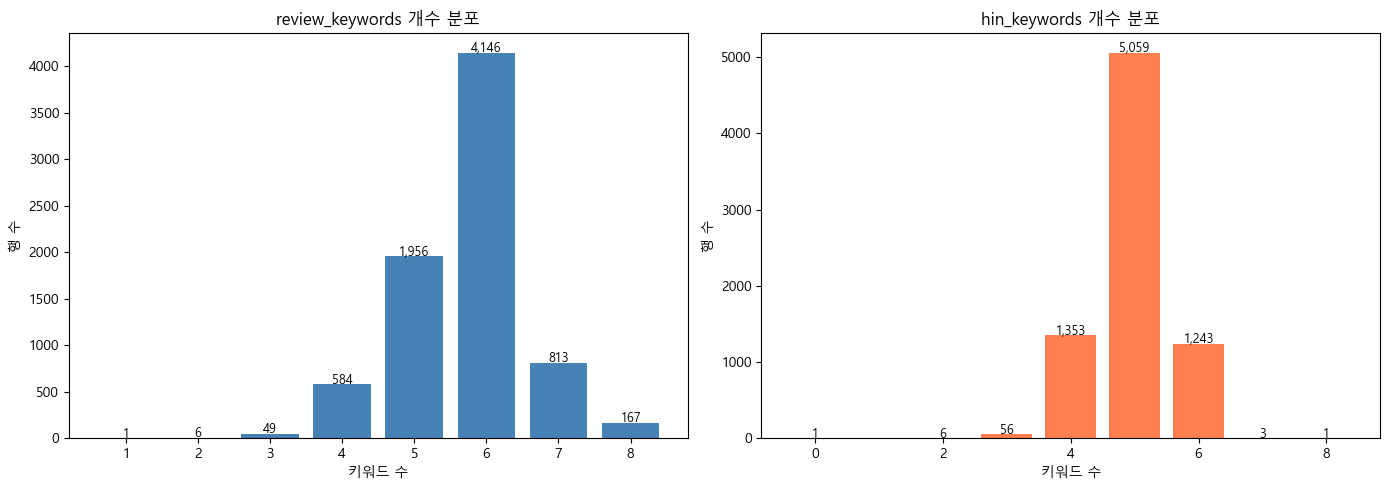

In [26]:
def kw_count(s):
    if not s or not s.strip(): return 0
    return len([k for k in s.split(',') if k.strip()])

df_s2['review_n'] = df_s2['review_keywords'].apply(kw_count)
df_s2['hin_n']    = df_s2['hin_keywords'].apply(kw_count)

print('=== review_keywords 개수 통계 ===')
print(df_s2['review_n'].describe().round(2))
print()
print('=== hin_keywords 개수 통계 ===')
print(df_s2['hin_n'].describe().round(2))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in [
    (axes[0], 'review_n', 'review_keywords 개수 분포', 'steelblue'),
    (axes[1], 'hin_n',    'hin_keywords 개수 분포',    'coral'),
]:
    dist = df_s2[col].value_counts().sort_index()
    ax.bar(dist.index, dist.values, color=color)
    ax.set_title(title)
    ax.set_xlabel('키워드 수')
    ax.set_ylabel('행 수')
    for x, y in zip(dist.index, dist.values):
        ax.text(x, y + 5, f'{y:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


review OR hin ≤3 전체: 102건
  ① 본문 <100자                          (내용 없음):   0건
  ② 본문 100~1000자     (내용 부족):   16건
  ③ 본문 >=1000자       (재추출 대상): 86건



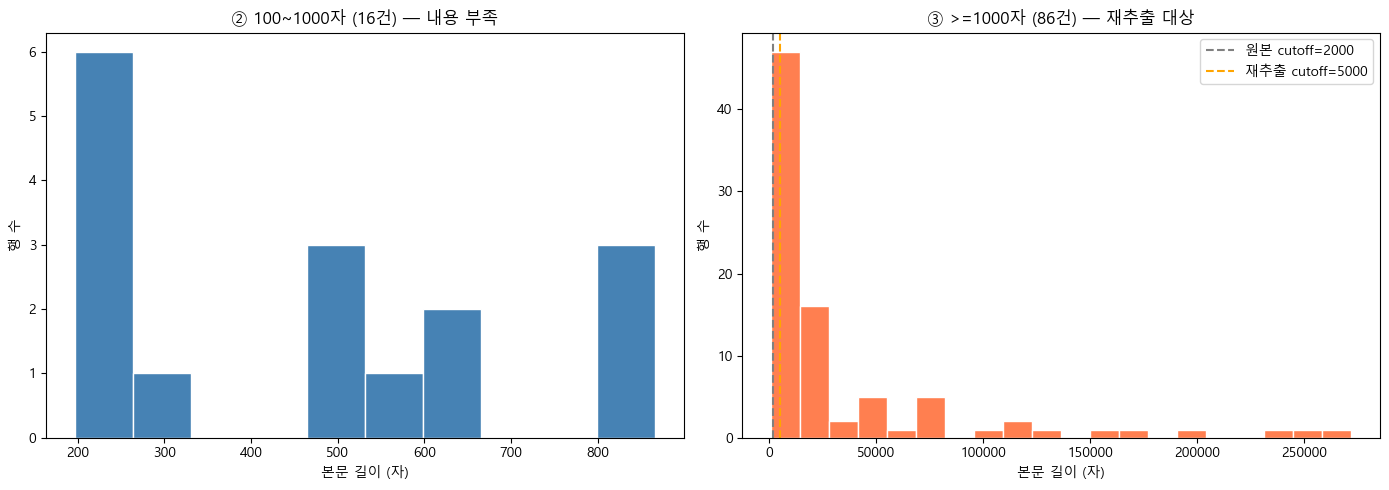

② 100~1000자 (16건) — 재추출해도 개선 어려움
                     검색어  본문길이  review_n  hin_n                  review_keywords      hin_keywords
   세븐일레븐 그래)여명1004 140ml   866         3      3                    숙취해소, 음주, 아쉬움        야식, 음주, 간식
    세븐일레븐 삼립)탕종빅땅콩샌드160g   807         6      3 고소함, 부드러움, 쫄깃함, 만족감, 식사대용, 크림넉넉함      땅콩, 식사대용, 간식
    세븐일레븐 시원)말랑키링(자두야)5g   800         4      3                말랑함, 촉감, 랜덤, 소장욕구       키링, 캐릭터, 간식
세븐일레븐 나무)시크릿쥬쥬립스틱Box(9구)   604         3      4                   패키지예쁨, 재구매, 만족 사탕, 딸기맛, 바나나맛, 메론
  세븐일레븐 시원)세이카라무네모찌캔디32g   599         3      4                   달콤함, 모찌캔디, 시원함   모찌, 라무네, 캔디, 간식
 세븐일레븐 농심)츄파춥스벚꽃에디션100틴    533         3      3                   할인행사, 선착순, 이벤트      할인, 프로모션, 간식
  세븐일레븐 에이트)짱구판박이젤리(곰모양)   510         3      3                      쫀득, 가성비, 만족       젤리, 간식, 곰모양
    세븐일레븐 PB)우리쌀사골떡국163g   485         2      3                           할인, 행사        명절, 설날, 떡국
     세븐일레븐 풀무원)깐메추리알270g   482         4      3              단백질식품, 반찬용, 믿음,

In [27]:
ORIG_CUTOFF         = 2000  # 원본 배치 추출 시 cutoff
REEXTRACT_THRESHOLD = 1000  # 재추출 대상 기준

# review OR hin 중 하나라도 ≤3인 행
low = df_s2[(df_s2['review_n'] <= 3) | (df_s2['hin_n'] <= 3)].copy()

too_short     = low[low['본문길이'] < 100]
within_thresh = low[(low['본문길이'] >= 100) & (low['본문길이'] < REEXTRACT_THRESHOLD)]
over_thresh   = low[low['본문길이'] >= REEXTRACT_THRESHOLD]

print(f'review OR hin ≤3 전체: {len(low)}건')
print(f'  ① 본문 <100자                          (내용 없음):   {len(too_short)}건')
print(f'  ② 본문 100~{REEXTRACT_THRESHOLD}자     (내용 부족):   {len(within_thresh)}건')
print(f'  ③ 본문 >={REEXTRACT_THRESHOLD}자       (재추출 대상): {len(over_thresh)}건')
print()

# ── 시각화 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(within_thresh['본문길이'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title(f'② 100~{REEXTRACT_THRESHOLD}자 ({len(within_thresh)}건) — 내용 부족')
axes[0].set_xlabel('본문 길이 (자)')
axes[0].set_ylabel('행 수')

axes[1].hist(over_thresh['본문길이'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(ORIG_CUTOFF, color='gray',   linestyle='--', label=f'원본 cutoff={ORIG_CUTOFF}')
axes[1].axvline(5000,         color='orange', linestyle='--', label='재추출 cutoff=5000')
axes[1].set_title(f'③ >={REEXTRACT_THRESHOLD}자 ({len(over_thresh)}건) — 재추출 대상')
axes[1].set_xlabel('본문 길이 (자)')
axes[1].set_ylabel('행 수')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── ② 상세 ────────────────────────────────────────────────────────────
print('=' * 70)
print(f'② 100~{REEXTRACT_THRESHOLD}자 ({len(within_thresh)}건) — 재추출해도 개선 어려움')
print('=' * 70)
print(within_thresh[['검색어', '본문길이', 'review_n', 'hin_n', 'review_keywords', 'hin_keywords']]
      .sort_values('본문길이', ascending=False).to_string(index=False))
print()

# ── ③ 상세 ────────────────────────────────────────────────────────────
print('=' * 70)
print(f'③ >={REEXTRACT_THRESHOLD}자 ({len(over_thresh)}건) — 재추출 대상 (cutoff=5000 적용)')
print('=' * 70)
over_thresh = over_thresh.copy()
over_thresh['재추출커버'] = over_thresh['본문길이'].apply(
    lambda x: 'O (5000자 이내)' if x <= 5000 else 'X (5000자도 초과)'
)
print(over_thresh[['검색어', '본문길이', 'review_n', 'hin_n', 'review_keywords', 'hin_keywords', '재추출커버']]
      .sort_values('본문길이', ascending=False).to_string(index=False))

In [28]:
review_low  = df_s2[df_s2['review_n'] <= 3][['검색어', '본문길이', 'review_n', 'review_keywords', 'hin_keywords']]
review_high = df_s2[df_s2['review_n'] >= 8][['검색어', '본문길이', 'review_n', 'review_keywords', 'hin_keywords']]
hin_low     = df_s2[df_s2['hin_n'] <= 3][['검색어', '본문길이', 'hin_n', 'review_keywords', 'hin_keywords']]
hin_high    = df_s2[df_s2['hin_n'] >= 7][['검색어', '본문길이', 'hin_n', 'review_keywords', 'hin_keywords']]

print(f'review <= 3개: {len(review_low)}건 / >= 8개: {len(review_high)}건')
print(f'hin    <= 3개: {len(hin_low)}건  / >= 7개: {len(hin_high)}건')
print()

for title, sub in [
    (f'review <= 3개 ({len(review_low)}건)', review_low.sort_values('review_n')),
    (f'review >= 8개 ({len(review_high)}건)', review_high.sort_values('review_n', ascending=False)),
    (f'hin <= 3개 ({len(hin_low)}건)',  hin_low.sort_values('hin_n')),
    (f'hin >= 7개 ({len(hin_high)}건)', hin_high.sort_values('hin_n', ascending=False)),
]:
    print('=' * 70)
    print(f'[{title}]')
    print('=' * 70)
    print(sub.to_string(index=False))
    print()


review <= 3개: 56건 / >= 8개: 167건
hin    <= 3개: 63건  / >= 7개: 4건

[review <= 3개 (56건)]
                     검색어   본문길이  review_n                          review_keywords              hin_keywords
      세븐일레븐 25설)제라헌베스트세트  11621         1                              소스 골라 먹는 재미         간편식, 신년, 설명절, KFC
    세븐일레븐 PB)우리쌀사골떡국163g    485         2                                   할인, 행사                명절, 설날, 떡국
     세븐일레븐 델리팜)참스볼캔디340g    239         2                                  가성비, 용량                          
세븐일레븐 페르)임페리얼12년트리플450ml   2088         2                                   할인, 행사                할인, 페이, 카드
      세븐일레븐 크라운)키커바프로45g  21695         2                              가성비, 2+1 행사               편의점, 할인, 행사
   세븐일레븐 드림)마블어벤져스스탠드10g  10840         2                                 멋있음, 기대됨 어린이날, 장난감, 피규어, 레고, 슈퍼히어로
  세븐일레븐 PB)말랑촉촉롱다리오징어35g  55690         2                                 촉촉함, 말랑함             간식, 디저트, PB상품
  세븐일레븐 비알)바나나쥬빌레우유240ml  72719         3  

In [ ]:
TARGETS_CSV = os.path.join(PROJECT_ROOT, 'data', 'processed', 'blog_reextract_targets.csv')

if not os.path.exists(TARGETS_CSV):
    print('재추출 targets 파일 없음 — batch_blog_reextract.py 실행 후 다시 확인')
else:
    targets = pd.read_csv(TARGETS_CSV, encoding='utf-8-sig')
    targets['본문내용']        = targets['본문내용'].fillna('')
    targets['review_keywords'] = targets['review_keywords'].fillna('')
    targets['hin_keywords']    = targets['hin_keywords'].fillna('')
    targets['본문길이']  = targets['본문내용'].str.len()
    targets['review_n'] = targets['review_keywords'].apply(kw_count)
    targets['hin_n']    = targets['hin_keywords'].apply(kw_count)

    no_body   = targets[targets['본문길이'] < 100]
    has_body  = targets[targets['본문길이'] >= 100]
    improved  = has_body[(has_body['review_n'] > 3) | (has_body['hin_n'] > 3)]
    still_low = has_body[(has_body['review_n'] <= 3) & (has_body['hin_n'] <= 3)]

    print(f'재추출 대상 총: {len(targets):,}건')
    print(f'  처리 불가 (본문 <100자):  {len(no_body):,}건 ({len(no_body)/len(targets)*100:.1f}%)')
    print(f'  처리 가능 (본문 >=100자): {len(has_body):,}건')
    print(f'    개선됨   (>3): {len(improved):,}건 ({len(improved)/len(has_body)*100:.1f}%)')
    print(f'    여전히 저품질: {len(still_low):,}건 ({len(still_low)/len(has_body)*100:.1f}%)')
    print()

    if 'orig_idx' in targets.columns:
        origin_df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
        origin_df['review_keywords'] = origin_df['review_keywords'].fillna('')
        origin_df['hin_keywords']    = origin_df['hin_keywords'].fillna('')
        before_df = origin_df.loc[targets['orig_idx'].values]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        pairs = [
            (axes[0], 'review_keywords', 'review_n', 'review_keywords 재추출 전/후'),
            (axes[1], 'hin_keywords',    'hin_n',    'hin_keywords 재추출 전/후'),
        ]
        for ax, b_col, a_col, title in pairs:
            b = before_df[b_col].apply(kw_count)
            a = targets[a_col]
            for d, c, label in [(b, 'steelblue', '재추출 전'), (a, 'coral', '재추출 후')]:
                dist = d.value_counts().sort_index()
                ax.plot(dist.index, dist.values, marker='o', color=c, label=label)
            ax.set_title(title)
            ax.set_xlabel('키워드 수')
            ax.set_ylabel('행 수')
            ax.legend()
        plt.tight_layout()
        plt.show()

    print('=== 재추출 후에도 저품질인 케이스 샘플 ===')
    print(still_low[['검색어', '본문길이', 'review_n', 'hin_n', 'review_keywords', 'hin_keywords']]
          .sort_values('본문길이', ascending=False).head(15).to_string(index=False))


## Step 4. 본격 키워드 분석
- Step 1~2 정제 완료된 `df_s2` 기준으로 분석


In [ ]:
all_review = [k.strip() for kws in df_s2['review_keywords'] for k in kws.split(',') if k.strip()]
all_hin    = [k.strip() for kws in df_s2['hin_keywords']    for k in kws.split(',') if k.strip()]

review_top = Counter(all_review).most_common(30)
hin_top    = Counter(all_hin).most_common(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
labels_r, counts_r = zip(*review_top)
axes[0].barh(labels_r[::-1], counts_r[::-1], color='steelblue')
axes[0].set_title('review_keywords 상위 30개')
axes[0].set_xlabel('등장 횟수')

labels_h, counts_h = zip(*hin_top)
axes[1].barh(labels_h[::-1], counts_h[::-1], color='coral')
axes[1].set_title('hin_keywords 상위 30개')
axes[1].set_xlabel('등장 횟수')

plt.tight_layout()
plt.show()

print(f'review_keywords 고유 키워드 수: {len(set(all_review)):,}개')
print(f'hin_keywords    고유 키워드 수: {len(set(all_hin)):,}개')


In [ ]:
bins   = [0, 300, 500, 1000, 2000, 5000, float('inf')]
labels = ['<300', '<500', '<1k', '<2k', '<5k', '>=5k']
df_s2['길이구간'] = pd.cut(df_s2['본문길이'], bins=bins, labels=labels, right=False)

summary = df_s2.groupby('길이구간', observed=True).agg(
    행수=('review_n', 'count'),
    review_평균=('review_n', 'mean'),
    hin_평균=('hin_n', 'mean')
).round(2)
print('=== 본문 길이별 키워드 품질 ===')
print(summary)


In [ ]:
suspicious = df_s2[(df_s2['본문길이'] < 300) & (df_s2['review_n'] >= 4)]
print(f'할루시네이션 의심 (본문<300자 & review>=4개): {len(suspicious)}건')
if len(suspicious) > 0:
    print(suspicious[['검색어', '본문길이', 'review_n', 'review_keywords']]
          .sort_values('본문길이').head(15).to_string(index=False))


In [ ]:
sample = df_s2[df_s2['본문길이'] >= 500].sample(15, random_state=42)
for _, row in sample.iterrows():
    print('=' * 60)
    print(f"[검색어]   {row['검색어']}")
    print(f"[본문길이]  {row['본문길이']:,}자")
    print(f"[본문]     {row['본문내용'][:200]}...")
    print(f"[review]   {row['review_keywords']}")
    print(f"[hin]      {row['hin_keywords']}")
    print()
